**A single neuron model for converting celsius to fehrenheit**

# Importing Libraries

In [2]:
import tensorflow as tf
import keras as ke
import pandas as pd
from matplotlib import pyplot as plt


In [3]:
print(tf.__version__)
print(ke.__version__)

2.17.1
3.5.0


In [49]:
# !pip install keras==2.17.1
#installing specific version of library

# Importing dataset

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
dataset=pd.read_csv("/content/drive/My Drive/Colab Notebooks/Datasets/Celsius+to+Fahrenheit.csv")

In [6]:
#another way to import dataset
# from google.colab import files
# uploaded=files.upload()

In [7]:
print(tf.config.list_physical_devices('GPU'))


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [8]:
!nvidia-smi


Mon Dec  2 05:10:25 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.104.05             Driver Version: 535.104.05   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  Tesla T4                       Off | 00000000:00:04.0 Off |                    0 |
| N/A   36C    P8               9W /  70W |      3MiB / 15360MiB |      0%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

In [9]:
df=dataset.copy()

In [10]:
df.head()

,Celsius,Fahrenheit
0,-50,-58.0
1,-40,-40.0
2,-30,-22.0
3,-20,-4.0
4,-10,14.0


In [11]:
x_train=df['Celsius']
y_train=df['Fahrenheit']

## Creating model and training

In [29]:
#create model
model=tf.keras.Sequential()
model.add(tf.keras.layers.Dense(units=1,input_shape=[1]))
model.summary()


/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
#compile model
model.compile(loss='mean_squared_error',optimizer=tf.keras.optimizers.Adam(1.0),metrics=['mean_squared_error'])

In [31]:
#training model
epoche_hist=model.fit(x_train,y_train,epochs=200)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step - loss: 2807.5432 - mean_squared_error: 2807.5432
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1343.5394 - mean_squared_error: 1343.5394
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 894.2176 - mean_squared_error: 894.2176
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1118.9448 - mean_squared_error: 1118.9448
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 1383.9602 - mean_squared_error: 1383.9602
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - loss: 1351.9998 - mean_squared_error: 1351.9998
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1096.7291 - mean_squared_error: 1096.7291
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - loss: 800.0983 - mean_squared_error: 800.0983
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 600.4685 - mean_squared_error: 600.4685
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 548.3663 - mean_squared_error: 548.3663
Epoch 

## Ploting loss

In [32]:
loss=epoche_hist.history['loss']

In [33]:
loss

[2807.543212890625,
 1343.5394287109375,
 894.2175903320312,
 1118.94482421875,
 1383.960205078125,
 1351.999755859375,
 1096.7291259765625,
 800.0982666015625,
 600.468505859375,
 548.3662719726562,
 603.0692749023438,
 671.3998413085938,
 675.7644653320312,
 597.8362426757812,
 471.70428466796875,
 350.9343566894531,
 277.0043640136719,
 260.6098327636719,
 280.5220642089844,
 299.9974670410156,
 290.54010009765625,
 246.86505126953125,
 185.2617950439453,
 130.3552703857422,
 100.0445785522461,
 96.45835876464844,
 106.8712387084961,
 113.2894287109375,
 104.06486511230469,
 79.87925720214844,
 51.217796325683594,
 30.378263473510742,
 23.644742965698242,
 28.213605880737305,
 35.20334243774414,
 36.186195373535156,
 28.525514602661133,
 16.128646850585938,
 5.8071370124816895,
 2.2874033451080322,
 5.320923805236816,
 10.543702125549316,
 13.043120384216309,
 10.807598114013672,
 5.6434102058410645,
 1.2740962505340576,
 0.3736526072025299,
 2.7864763736724854,
 6.049858570098877,


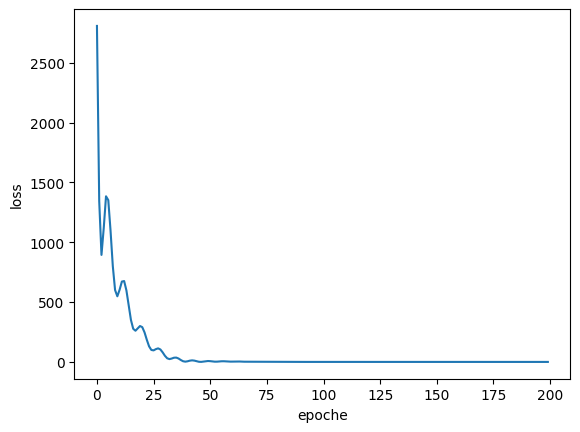

In [36]:
from matplotlib import pyplot as plt
plt.plot(loss)
plt.xlabel('epoche')
plt.ylabel('loss')
plt.show()

In [37]:
model.get_weights()

[array([[1.8000286]], dtype=float32), array([32.00119], dtype=float32)]

## Evaluating

In [38]:
import numpy as np

In [39]:
temp_c = 0 #@param {type:"number"}
temp_f = model.predict(np.array([temp_c]))
temp_f


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step


array([[32.00119]], dtype=float32)